In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [36]:
df=pd.read_csv(r'D:\AI-ML Code & Projects\Projects\House Price Prediction\data\raw\housing.csv')

In [37]:
df.shape

(20640, 10)

In [38]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [40]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [44]:
df.sample()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
17366,-120.43,34.95,43.0,2020.0,344.0,692.0,310.0,3.6815,181800.0,<1H OCEAN


In [45]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [48]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df["total_bedrooms"].mean())

In [49]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

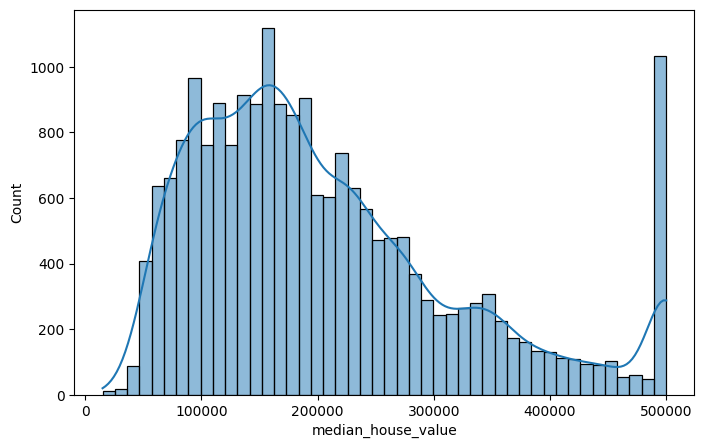

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"],kde=True)
plt.show()

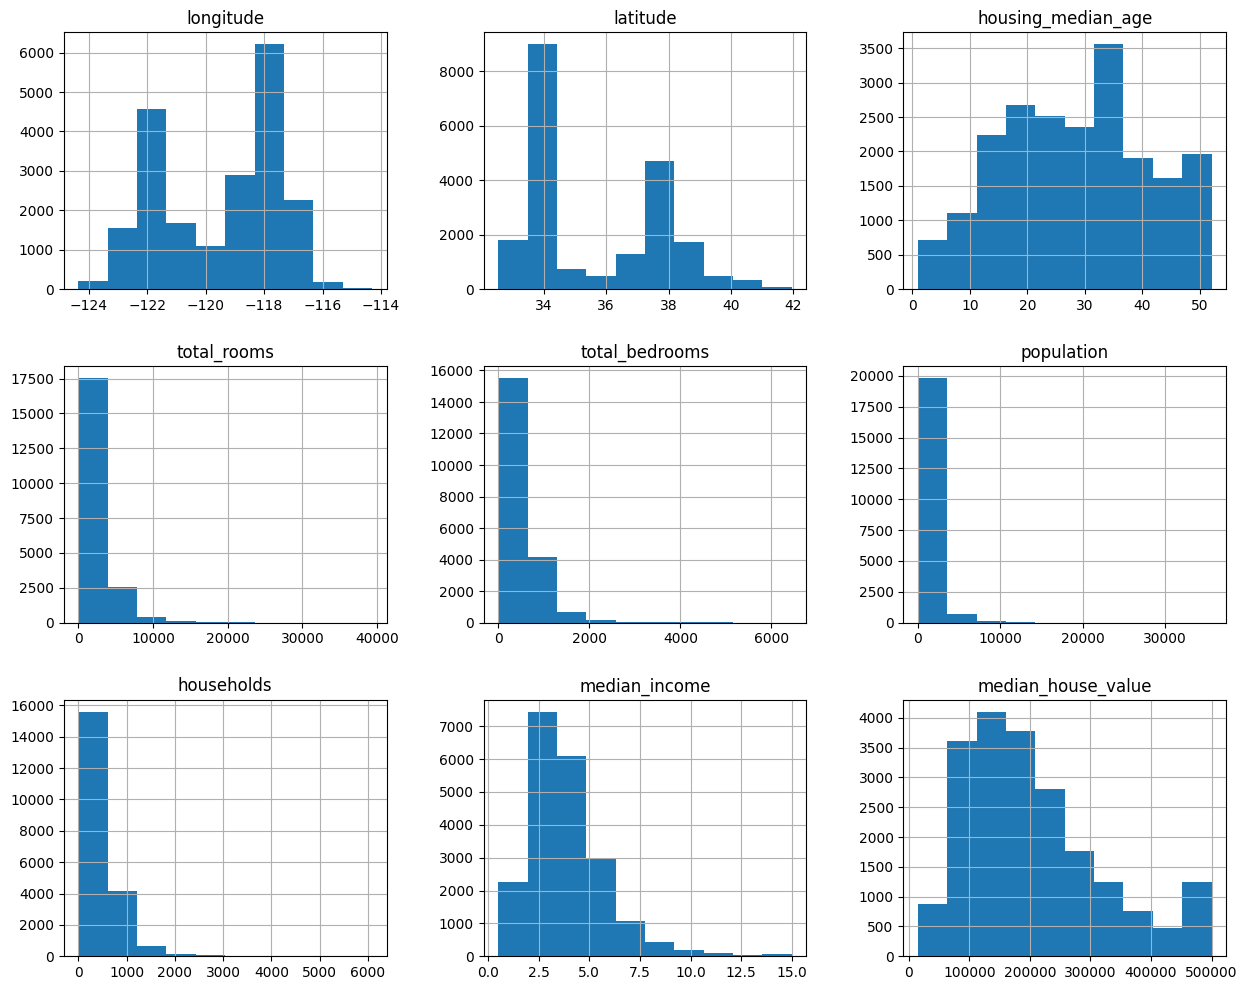

In [55]:
df.hist(figsize=(15,12))
plt.show()

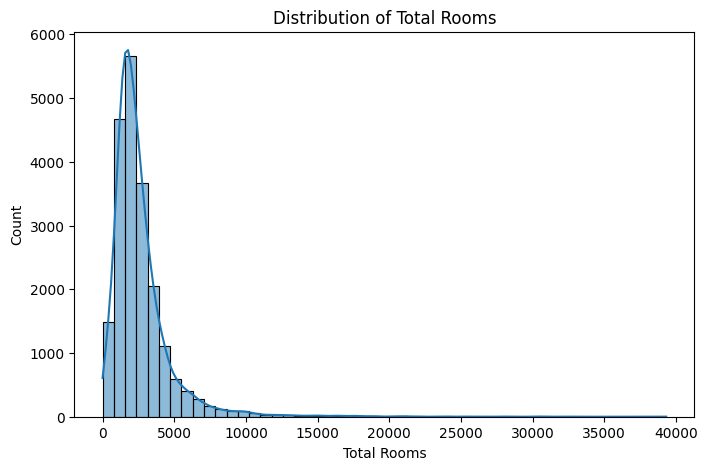

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(df["total_rooms"],bins=50,kde=True)
plt.title("Distribution of Total Rooms")
plt.xlabel("Total Rooms")
plt.ylabel("Count")
plt.show()

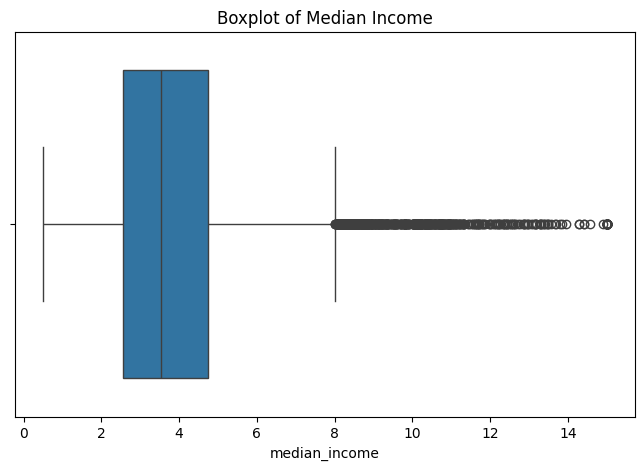

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["median_income"])
plt.title("Boxplot of Median Income")
plt.show()

In [60]:
Q1=df["median_income"].quantile(0.25)
Q3=df["median_income"].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outliers=df[(df["median_income"]<lower_bound) | (df["median_income"]>upper_bound)]

print("Lower Bound:",lower_bound)
print("Upper Bound:",upper_bound)
print("Number of Outliers:",len(outliers))
print("Percentage:",round(len(outliers)/len(df)*100,2),"%")

Lower Bound: -0.7063750000000004
Upper Bound: 8.013024999999999
Number of Outliers: 681
Percentage: 3.3 %


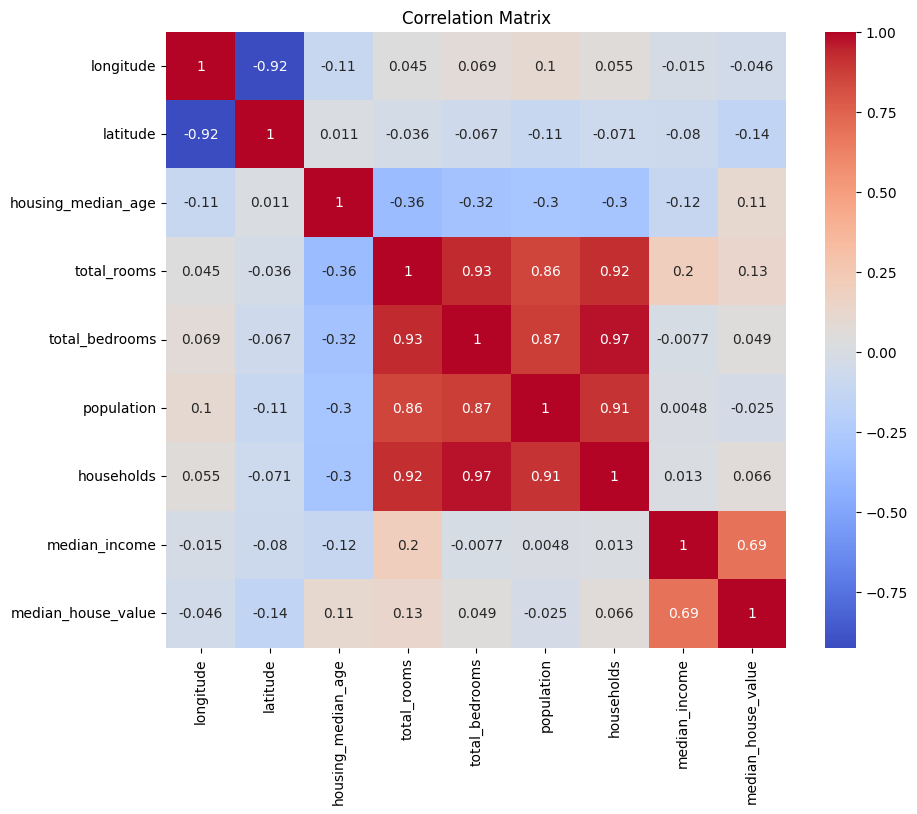

In [62]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

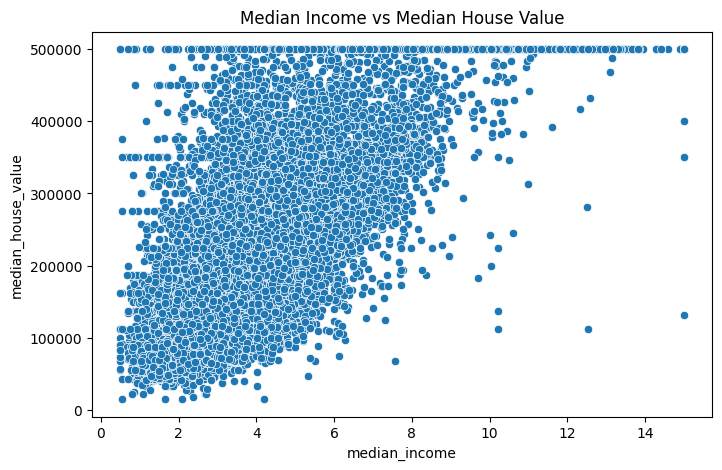

In [63]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value"
)
plt.title("Median Income vs Median House Value")
plt.show()

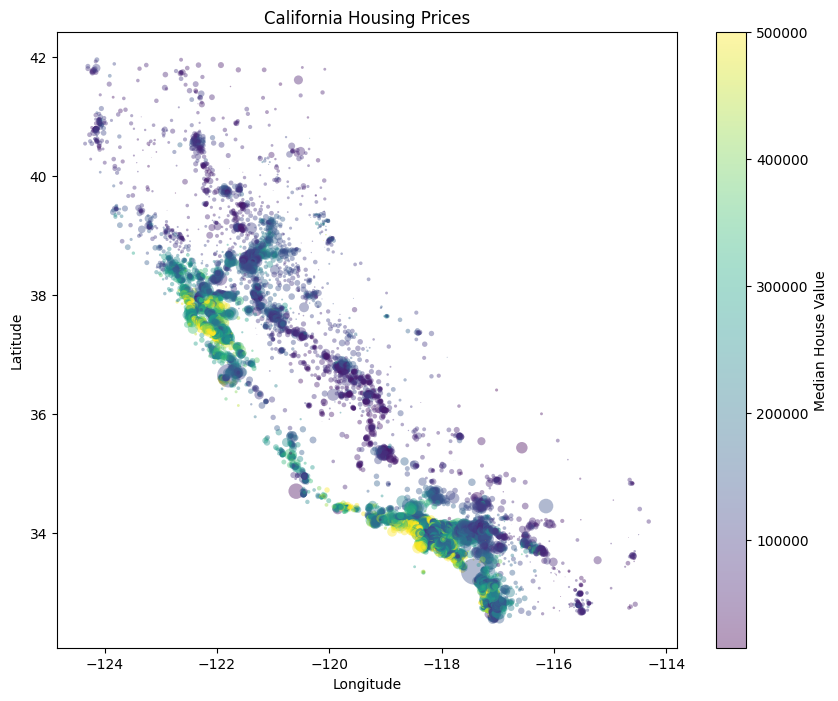

In [67]:
plt.figure(figsize=(10,8))

plt.scatter(df["longitude"],df["latitude"],alpha=0.4,s=df["population"]/100,c=df["median_house_value"],cmap="viridis",edgecolors="none")
plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices")
plt.show()

In [68]:
df['rooms_per_household']=df['total_rooms']/df['households']

In [69]:
df[["total_rooms","households","rooms_per_household"]].head()

,total_rooms,households,rooms_per_household
0,880.0,126.0,6.984127
1,7099.0,1138.0,6.238137
2,1467.0,177.0,8.288136
3,1274.0,219.0,5.817352
4,1627.0,259.0,6.281853


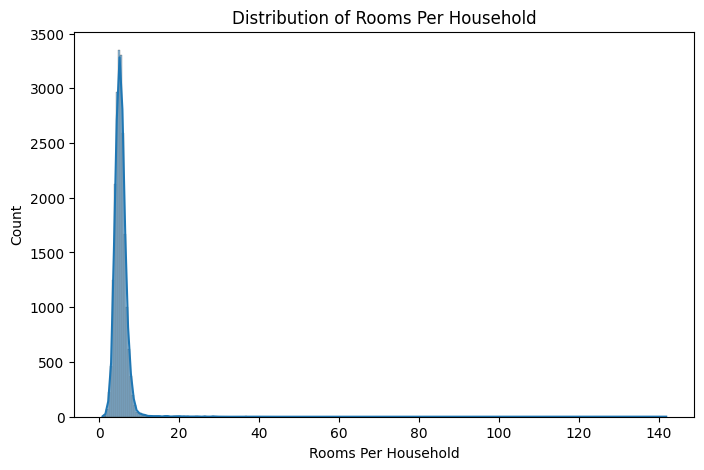

In [70]:
plt.figure(figsize=(8,5))
sns.histplot(df["rooms_per_household"],kde=True)
plt.title("Distribution of Rooms Per Household")
plt.xlabel("Rooms Per Household")
plt.ylabel("Count")
plt.show()

In [76]:
df["population_per_household"]=df["population"]/df['households']
df[["population_per_household",'population','households']]

,population_per_household,population,households
0,2.555556,322.0,126.0
1,2.109842,2401.0,1138.0
2,2.802260,496.0,177.0
3,2.547945,558.0,219.0
4,2.181467,565.0,259.0
...,...,...,...
20635,2.560606,845.0,330.0
20636,3.122807,356.0,114.0
20637,2.325635,1007.0,433.0
20638,2.123209,741.0,349.0


In [77]:
df["bedrooms_per_room"]=df["total_bedrooms"]/df["total_rooms"]

In [78]:
df[["rooms_per_household","bedrooms_per_room","population_per_household","median_house_value"]].corr()

,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
rooms_per_household,1.000000,-0.347501,-0.004852,0.151948
bedrooms_per_room,-0.347501,1.000000,0.002373,-0.220049
population_per_household,-0.004852,0.002373,1.000000,-0.023737
median_house_value,0.151948,-0.220049,-0.023737,1.000000
